"""
Final Clean J-V Curve — Fig. 9b Replica
=========================================
Reads simulation #4 (illuminated single-shot) from IV_doping.iv
Produces a publication-quality J-V curve with:
  - Jsc, Voc, FF, PCE annotated in a box
  - Maximum Power Point marked
  - Power curve overlaid on secondary axis
  - Fill Factor rectangle shaded

HOW TO RUN:
  Place in same folder as IV_doping.iv
  python plot_JV_final.py
"""

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch

In [7]:
FILENAME   = "IV_doping.iv"
TARGET_SIM = 4          # simulation #4 = illuminated single-shot
PIN        = 100.0      # incident power mW/cm²

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — PARSE
# Key fix: SCAPS puts a blank line BETWEEN the data header and the first row,
# so we must not reset in_data on the first blank line.
# ─────────────────────────────────────────────────────────────────────────────
voltage   = []
jtot      = []
in_block  = False
in_data   = False
voc_scaps = jsc_scaps = ff_scaps = pce_scaps = None

with open(FILENAME, "r", encoding="utf-8", errors="replace") as f:
    for line in f:

        # detect simulation block header
        m = re.match(r"Single shot simulation #\s+(\d+)", line)
        if m:
            sim = int(m.group(1))
            if sim == TARGET_SIM:
                in_block = True
                in_data  = False
            elif sim > TARGET_SIM:
                break
            else:
                in_block = False
            continue

        # stop at batch section
        if re.match(r"Batch simulation #", line, re.IGNORECASE):
            break

        if not in_block:
            continue

        # detect data table header
        if "v(V)" in line and "jtot" in line:
            in_data = True
            continue

        # read data rows
        if in_data:
            # skip blank lines — only end data if we already have rows
            if line.strip() == "":
                if len(voltage) > 0:
                    in_data = False
                continue
            parts = line.strip().split()
            if len(parts) >= 2:
                try:
                    voltage.append(float(parts[0]))
                    jtot.append(float(parts[1]))
                    continue
                except ValueError:
                    in_data = False

        # read SCAPS solar cell parameter summary
        if in_block and not in_data:
            m2 = re.match(r"\s*Voc\s*=\s*([\d.eE+\-]+)", line)
            m3 = re.match(r"\s*Jsc\s*=\s*([\d.eE+\-]+)", line)
            m4 = re.match(r"\s*FF\s*=\s*([\d.eE+\-]+)",  line)
            m5 = re.match(r"\s*eta\s*=\s*([\d.eE+\-]+)",  line)
            if m2: voc_scaps = float(m2.group(1))
            if m3: jsc_scaps = float(m3.group(1))
            if m4: ff_scaps  = float(m4.group(1))
            if m5: pce_scaps = float(m5.group(1))

voltage = np.array(voltage)
jtot    = np.array(jtot)

if len(voltage) == 0:
    raise SystemExit(
        f"ERROR: No data rows found for simulation #{TARGET_SIM} in {FILENAME}"
    )

print(f"Parsed {len(voltage)} data points from simulation #{TARGET_SIM}")

Parsed 41 data points from simulation #4


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — EXTRACT ILLUMINATED REGION (J <= 0 in SCAPS convention)
# ─────────────────────────────────────────────────────────────────────────────
mask  = jtot <= 0.0
v_ill = voltage[mask]
j_ill = np.abs(jtot[mask])

if len(v_ill) == 0:
    raise SystemExit("ERROR: No illuminated (J<=0) data points found.")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — CALCULATE PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────

# Jsc
jsc_calc = float(j_ill[0]) if v_ill[0] == 0.0 else float(np.interp(0.0, v_ill, j_ill))

# Voc
sign_changes = np.where(np.diff(np.sign(jtot)))[0]
if sign_changes.size > 0:
    idx      = sign_changes[0]
    voc_calc = float(np.interp(0.0,
                                [jtot[idx], jtot[idx + 1]],
                                [voltage[idx], voltage[idx + 1]]))
else:
    voc_calc = float(v_ill[-1])

# Power, MPP, FF, PCE
power    = v_ill * j_ill
mpp_idx  = int(np.argmax(power))
vmpp     = float(v_ill[mpp_idx])
jmpp     = float(j_ill[mpp_idx])
pmax     = float(power[mpp_idx])
ff_calc  = (pmax / (jsc_calc * voc_calc)) * 100.0
pce_calc = (pmax / PIN) * 100.0

# Prefer SCAPS summary values (extrapolated, more accurate)
jsc = jsc_scaps if jsc_scaps is not None else jsc_calc
voc = voc_scaps if voc_scaps is not None else voc_calc
ff  = ff_scaps  if ff_scaps  is not None else ff_calc
pce = pce_scaps if pce_scaps is not None else pce_calc

print("\n-- Solar Cell Parameters -----------------------")
print(f"  Jsc  = {jsc:.4f}  mA/cm2")
print(f"  Voc  = {voc:.4f}  V")
print(f"  FF   = {ff:.4f}  %")
print(f"  PCE  = {pce:.4f}  %")
print(f"  Vmpp = {vmpp:.4f}  V")
print(f"  Jmpp = {jmpp:.4f}  mA/cm2")
print(f"  Pmax = {pmax:.4f}  mW/cm2")
print("------------------------------------------------")


-- Solar Cell Parameters -----------------------
  Jsc  = 34.5752  mA/cm2
  Voc  = 1.0436  V
  FF   = 59.0498  %
  PCE  = 21.3061  %
  Vmpp = 0.7200  V
  Jmpp = 29.5894  mA/cm2
  Pmax = 21.3044  mW/cm2
------------------------------------------------


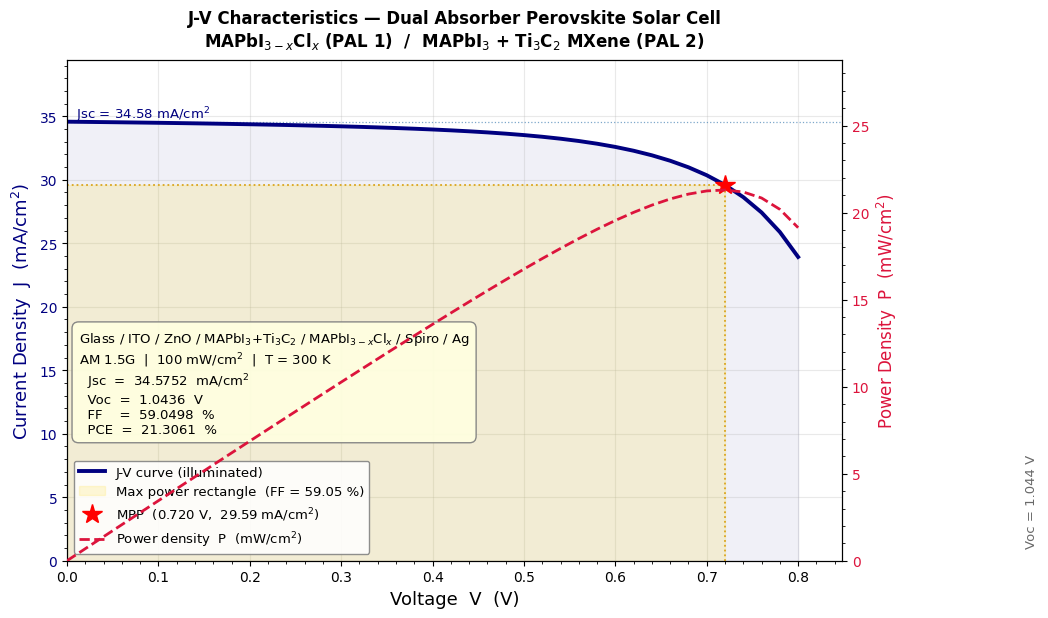

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6.5))
ax2 = ax1.twinx()

# J-V curve
ax1.plot(v_ill, j_ill,
         color="navy", linewidth=2.8, zorder=4,
         label="J-V curve (illuminated)")
ax1.fill_between(v_ill, j_ill, alpha=0.06, color="navy", zorder=1)

# Power density curve
ax2.plot(v_ill, power,
         color="crimson", linewidth=2.0, linestyle="--", zorder=3,
         label="Power density  P  (mW/cm$^2$)")
ax2.set_ylabel("Power Density  P  (mW/cm$^2$)", fontsize=12, color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson", labelsize=10)
ax2.set_ylim(bottom=0.0, top=pmax * 1.35)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Fill Factor shaded rectangle
ax1.fill_between([0.0, vmpp], [0.0, 0.0], [jmpp, jmpp],
                 alpha=0.14, color="gold", zorder=2,
                 label=f"Max power rectangle  (FF = {ff:.2f} %)")
ax1.plot([vmpp, vmpp], [0.0, jmpp],
         color="goldenrod", linewidth=1.3, linestyle=":", zorder=3)
ax1.plot([0.0, vmpp], [jmpp, jmpp],
         color="goldenrod", linewidth=1.3, linestyle=":", zorder=3)

# MPP marker
ax1.plot(vmpp, jmpp, "r*", markersize=15, zorder=6,
         label=f"MPP  ({vmpp:.3f} V,  {jmpp:.2f} mA/cm$^2$)")

# Jsc dotted line and label
ax1.axhline(jsc, color="steelblue", linewidth=0.9, linestyle=":", alpha=0.7)
ax1.text(0.01, jsc + 0.25, f"Jsc = {jsc:.2f} mA/cm$^2$",
         fontsize=9.5, color="navy")

# Voc dotted line and label
ax1.axvline(voc, color="dimgray", linewidth=0.9, linestyle=":", alpha=0.7)
ax1.text(voc + 0.005, 1.0, f"Voc = {voc:.3f} V",
         fontsize=9.5, color="dimgray", rotation=90, va="bottom")

# Parameter annotation box
param_text = (
    "Glass / ITO / ZnO / MAPbI$_3$+Ti$_3$C$_2$ / MAPbI$_{3-x}$Cl$_x$ / Spiro / Ag\n"
    "AM 1.5G  |  100 mW/cm$^2$  |  T = 300 K\n"
    f"  Jsc  =  {jsc:.4f}  mA/cm$^2$\n"
    f"  Voc  =  {voc:.4f}  V\n"
    f"  FF    =  {ff:.4f}  %\n"
    f"  PCE  =  {pce:.4f}  %"
)
ax1.text(0.015, 0.46, param_text,
         transform=ax1.transAxes,
         fontsize=9.5, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.5",
                   facecolor="lightyellow",
                   edgecolor="gray",
                   alpha=0.93),
         zorder=7)

# Axis labels and formatting
ax1.set_xlabel("Voltage  V  (V)", fontsize=13)
ax1.set_ylabel("Current Density  J  (mA/cm$^2$)", fontsize=13, color="navy")
ax1.tick_params(axis="y", labelcolor="navy", labelsize=10)
ax1.tick_params(axis="x", labelsize=10)
ax1.set_xlim(left=0.0, right=float(v_ill[-1]) * 1.06)
ax1.set_ylim(bottom=0.0, top=float(jsc) * 1.14)
ax1.set_title(
    "J-V Characteristics — Dual Absorber Perovskite Solar Cell\n"
    "MAPbI$_{3-x}$Cl$_x$ (PAL 1)  /  MAPbI$_3$ + Ti$_3$C$_2$ MXene (PAL 2)",
    fontsize=12, fontweight="bold", pad=10
)
ax1.grid(True, alpha=0.28, zorder=0)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=9.5, loc="lower left",
           framealpha=0.88, edgecolor="gray")

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — SAVE
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("JV_final_annotated.png", dpi=300, bbox_inches="tight")
print("\nSaved --> JV_final_annotated.png")
plt.show()


Saved --> JV_final_annotated.png


<Figure size 640x480 with 0 Axes>